# 01 — Data acquisition and metadata

I query the Allen Brain Observatory Visual Coding metadata through AllenSDK. I do not include raw NWB files in Git because the dataset is large; I cache them locally only when I explicitly request download.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [2]:
from v1_manifold.data_access import get_boc, query_v1_natural_movie_experiments, save_experiment_catalog, download_selected_nwb_files

boc = get_boc(paths.allen_manifest)
experiments = query_v1_natural_movie_experiments(boc, cfg)
metadata_path = save_experiment_catalog(experiments, paths.external_metadata)
print(f"Saved {len(experiments)} selected experiments to {metadata_path}")
experiments.head()

c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Saved 3 selected experiments to C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\external\allen_v1_natural_movie_experiments.csv


,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking,putative_layer
0,500855614,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),94,511507650,three_session_C,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True,L2/3
1,500964514,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),97,511509529,three_session_B,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3
2,501271265,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),100,511509529,three_session_A,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3


In [3]:
# I keep NWB downloads off by default because a full Visual Coding cache is large.
# To actually download the selected files from this notebook, set cfg["allen"]["download_nwb"] = True first.
downloaded = download_selected_nwb_files(boc, experiments, download=bool(cfg["allen"].get("download_nwb", False)))
print("Downloaded experiment IDs:", downloaded)

Downloaded experiment IDs: []


,cre_line,imaging_depth,putative_layer,n_experiments
0,Cux2-CreERT2,175,L2/3,3


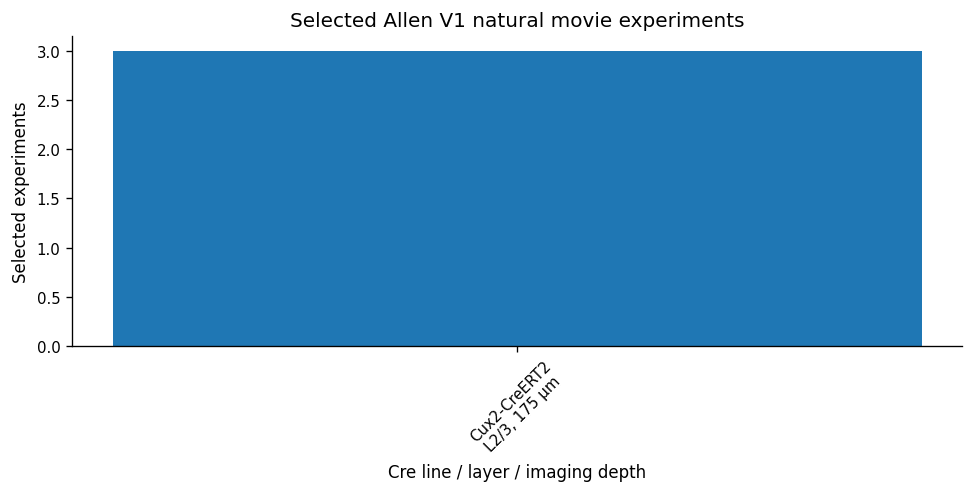

In [4]:
import matplotlib.pyplot as plt

cre_depth_summary = (
    experiments
    .groupby(["cre_line", "imaging_depth", "putative_layer"])
    .size()
    .reset_index(name="n_experiments")
    .sort_values(["putative_layer", "cre_line", "imaging_depth"])
)

display(cre_depth_summary)

save_table(
    cre_depth_summary,
    paths.tables_dir / "01_selected_experiments_by_cre_depth_layer.csv"
)

fig, ax = plt.subplots(figsize=(8, 4))

labels = (
    cre_depth_summary["cre_line"].astype(str)
    + "\n"
    + cre_depth_summary["putative_layer"].astype(str)
    + ", "
    + cre_depth_summary["imaging_depth"].astype(str)
    + " μm"
)

ax.bar(labels, cre_depth_summary["n_experiments"])

ax.set_xlabel("Cre line / layer / imaging depth")
ax.set_ylabel("Selected experiments")
ax.set_title("Selected Allen V1 natural movie experiments")
ax.tick_params(axis="x", rotation=45)

save_figure(fig, paths.figures_dir / "01_selected_experiments_by_cre_depth_layer.png")
plt.show()